# Homework 3: Logistic Regression
**Name:** Aragya Goyal
**Student ID:** 4541458
**D value:** 58

In [1]:
# Import Packages
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# Define Globals
D = 58

### Question 1: Building a Logistic Regression Classifier
#### Part A: Data Preparation

In [2]:
# Load the data file
data = np.loadtxt('./input/hw3_data1.txt', delimiter=',')

# Define X and y
X = data[:, :-1]
y = data[:, -1]

# Add bias column to X
X = np.hstack((np.ones((X.shape[0], 1)), X))

# Output shapes of X and y
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (100, 3)
Shape of y: (100,)


#### Part B: Data Visualization

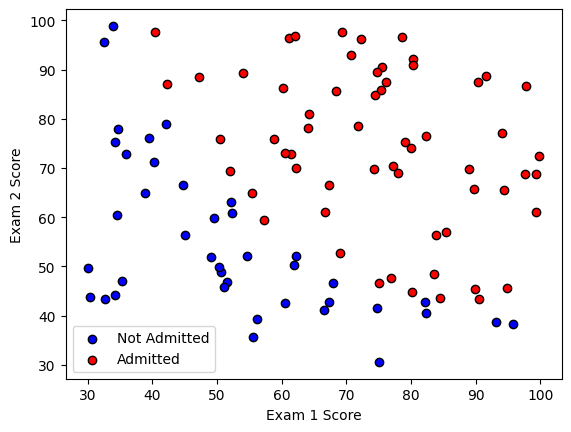

In [3]:
# Create scatter plot of the data
# Plot each class separately to get proper legend
plt.scatter(X[y==0, 1], X[y==0, 2], c='blue', edgecolors='k', label='Not Admitted')
plt.scatter(X[y==1, 1], X[y==1, 2], c='red', edgecolors='k', label='Admitted')
plt.legend()
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.savefig('./output/ps3-1-b.png')
plt.show()

#### Part C: Train/Test Split

In [4]:
# Split the data into training and test sets
np.random.seed(D)

# Shuffle the data
indices = np.random.permutation(X.shape[0])
X = X[indices]
y = y[indices]

# Split the data (90% training, 10% test)
split_index = int(0.9 * X.shape[0])
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Output number of samples in training and test sets
print("Number of training samples:", X_train.shape[0])
print("Number of test samples:", X_test.shape[0])

Number of training samples: 90
Number of test samples: 10


#### Part D: Sigmoid Function

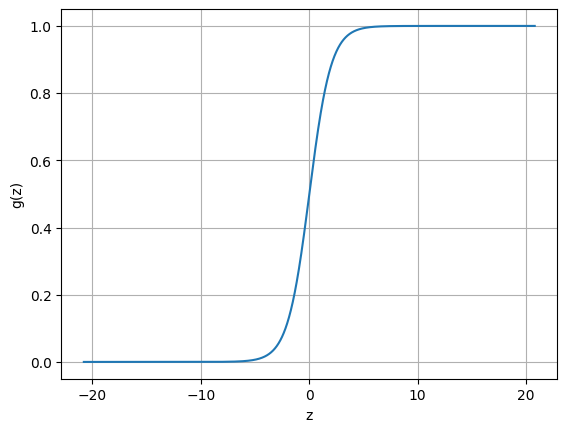

In [7]:
# Implement sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Test sigmoid function
z = np.arange(-(15 + D/10), (15 + D/10), 0.01)
g_z = sigmoid(z)

# Plot sigmoid function
plt.plot(z, g_z)
plt.xlabel('z')
plt.ylabel('g(z)')
plt.grid(True)
plt.savefig('./output/ps3-1-d.png')
plt.show()

**Text Response:**

1. g(z) first exceeds 0.1 at around z = -2
2. g(z) first exceeds 0.9 at around z = 2

#### Part E: Cost Function and Gradient

In [ ]:
# Implement logistic regression cost function
def cost_function(theta, X, y):
    m = X.shape[0]
    h = sigmoid(theta.T @ X)
    cost = -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))
    return cost

# Implement logistic regression gradient function
def gradFunction(theta, X, y):
    m = X.shape[0]
    h = sigmoid(theta.T @ X)
    gradient = (1/m) * ((h-y) @ X)
    return gradient

    